In [32]:
import sys
sys.path.insert(0, '../..')
from dependencies import *
from constants import *
from paths import *
import helper_functions

In [45]:
def plot_scatter_panel(ax, df, color, title, groupby_subject=False, annotate=False, lim = [-0.02, 0.35]):

    if groupby_subject:
        agg       = df.groupby('subject')[['r_att', 'r_ign']].mean()
        r_att     = agg['r_att'].values
        r_ign     = agg['r_ign'].values
        labels    = [s.replace('sub-', '') for s in agg.index]
    else:
        r_att  = df['r_att'].values
        r_ign  = df['r_ign'].values
        labels = df['subject'].str.replace('sub-', '').values

    correct = r_att > r_ign
    acc     = correct.mean()

    ax.scatter(r_att[correct],  r_ign[correct],
               color=color, edgecolors='white', linewidths=0.5,
               s=65, zorder=3, marker='o', label=f'Correct ({acc:.0%})')
    ax.scatter(r_att[~correct], r_ign[~correct],
               color=color, edgecolors='red', linewidths=0.8,
               s=65, zorder=3, marker='X', label=f'Incorrect ({1-acc:.0%})')

    if annotate:
        for s, x, y in zip(labels, r_att, r_ign):
            ax.annotate(s, (x, y),
                        textcoords='offset points', xytext=(5, 3),
                        fontsize=6.5, color=color, alpha=0.85)

    all_r = np.concatenate([r_att, r_ign])
    ax.plot(lim, lim, 'k--', linewidth=0.9, alpha=0.5, zorder=2)
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_aspect('equal')
    ax.set_xlabel(r'$r_{att}$', fontsize=9)
    ax.set_ylabel(r'$r_{ign}$', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7.5, loc='upper left', framealpha=0.9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=8)

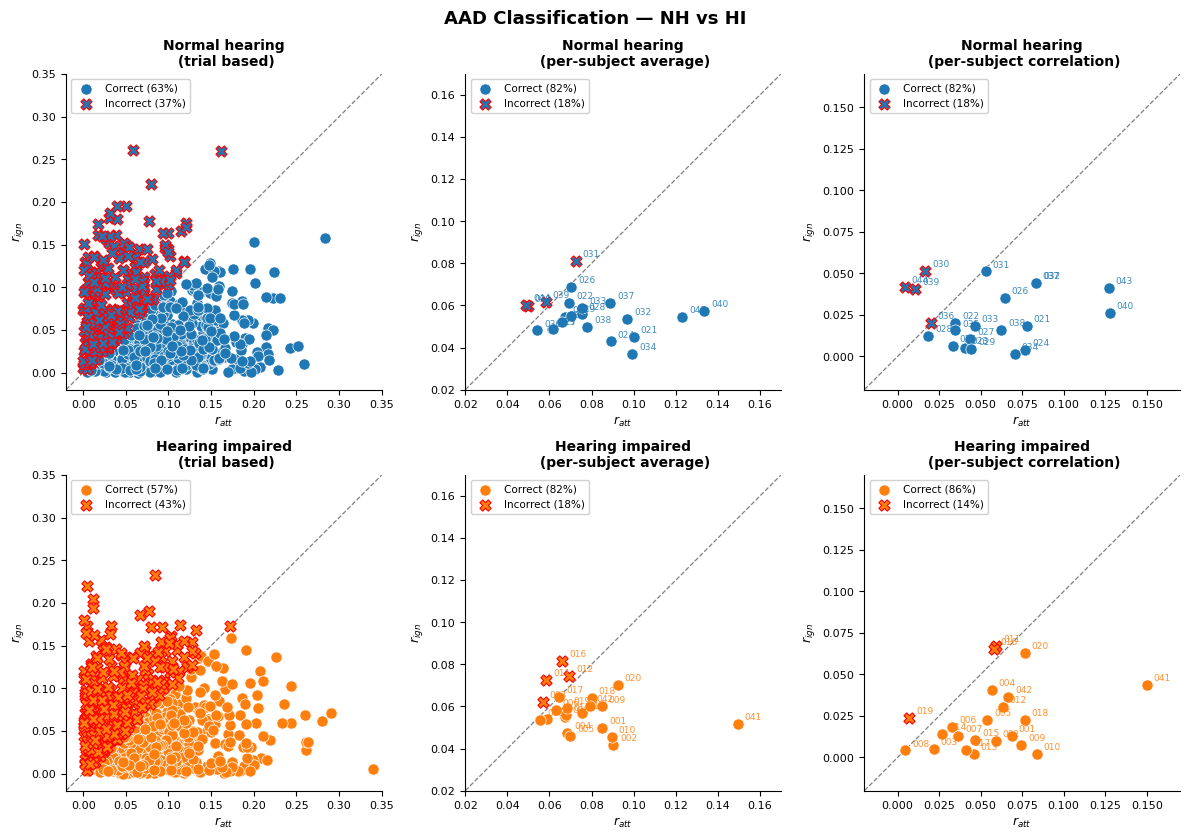

In [49]:
results_nh = pd.read_csv('results_nh.csv')
results_hi = pd.read_csv('results_hi.csv')

results_nh_cat = pd.read_csv('results_nh_cat.csv')
results_hi_cat = pd.read_csv('results_hi_cat.csv')

fig, axes = plt.subplots(2, 3, figsize=(12, 8.5))
ax_nh1, ax_nh2, ax_nh3 = axes[0]
ax_hi1, ax_hi2, ax_hi3 = axes[1]

plot_scatter_panel(
    ax_nh1, results_nh,
    color='tab:blue',
    title='Normal hearing\n (trial based)',
    groupby_subject=False
)
plot_scatter_panel(
    ax_nh2, results_nh,
    color='tab:blue',
    title='Normal hearing\n (per-subject average)',
    groupby_subject=True,
    annotate=True,
    lim=[0.02,0.17]
)
plot_scatter_panel(
    ax_nh3, results_nh_cat,
    color='tab:blue',
    title='Normal hearing\n (per-subject correlation)',
    groupby_subject=False,
    annotate=True,
    lim=[-0.02,0.17]
)


plot_scatter_panel(
    ax_hi1, results_hi,
    color='tab:orange',
    title='Hearing impaired\n (trial based)',
    groupby_subject=False
)
plot_scatter_panel(
    ax_hi2, results_hi,
    color='tab:orange',
    title='Hearing impaired\n (per-subject average)',
    groupby_subject=True,
    annotate=True,
    lim=[0.02,0.17]
)
plot_scatter_panel(
    ax_hi3, results_hi_cat,
    color='tab:orange',
    title='Hearing impaired\n (per-subject correlation)',
    groupby_subject=False,
    annotate=True,
    lim=[-0.02,0.17]
)

fig.suptitle('AAD Classification — NH vs HI', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(FUGLSANG_FIGURES_DIR / 'aad_scatter_nh_hi.png', dpi=170, bbox_inches='tight')
plt.show()